In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images Shape:", X_train.shape)
print("Testing Images Shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape: (60000, 28, 28)
Testing Images Shape: (10000, 28, 28)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [ ]:
model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dropout(0.3),  # Add dropout after the first dense layer
    Dense(64, activation='relu'),
    Dropout(0.3),  # Add dropout after the second dense layer
    Dense(10, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history= model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8719 - loss: 0.4221 - val_accuracy: 0.9657 - val_loss: 0.1222
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9398 - loss: 0.2073 - val_accuracy: 0.9713 - val_loss: 0.0983
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9514 - loss: 0.1648 - val_accuracy: 0.9738 - val_loss: 0.0843
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9583 - loss: 0.1395 - val_accuracy: 0.9782 - val_loss: 0.0727
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9621 - loss: 0.1268 - val_accuracy: 0.9762 - val_loss: 0.0827
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9660 - loss: 0.1130 - val_accuracy: 0.9782 - val_loss: 0.0764
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9685 - loss: 0.1060 - val_accuracy: 0.9797 - val_loss: 0.0653
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9701 - loss: 0.0988 -

In [ ]:
train_loss, train_accuracy = model.evaluate(
    X_train,
    y_train,
    verbose=0
)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9874833226203918


In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Testing Accuracy:", test_accuracy)

Testing Accuracy: 0.9775000214576721


In [ ]:
print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

Training Accuracy : 0.9874833226203918
Testing Accuracy  : 0.9775000214576721


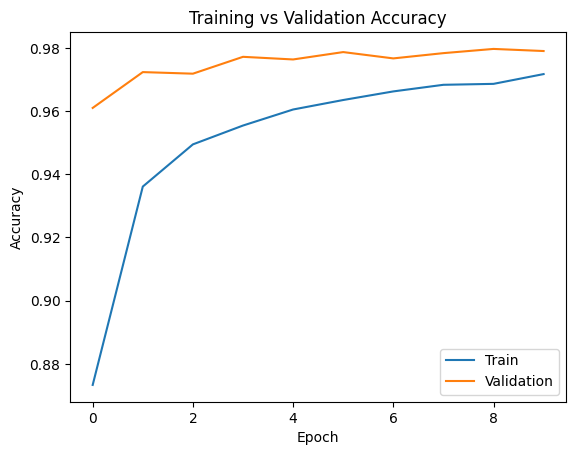

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

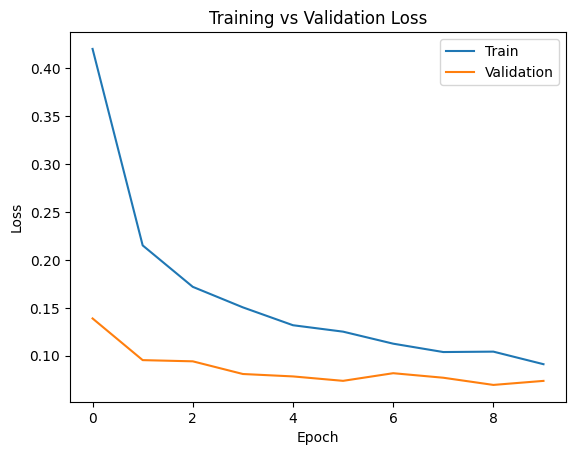

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


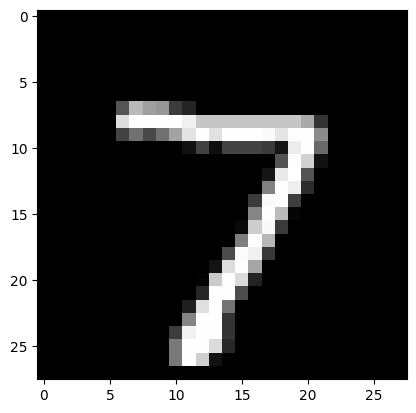

Actual: 7
Predicted: 7


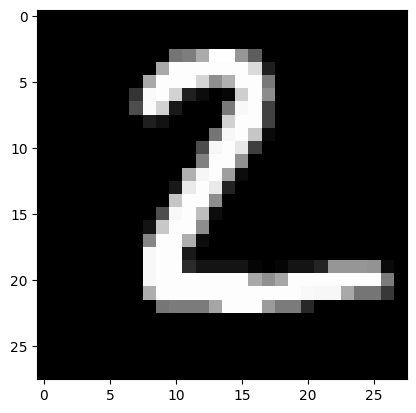

Actual: 2
Predicted: 2


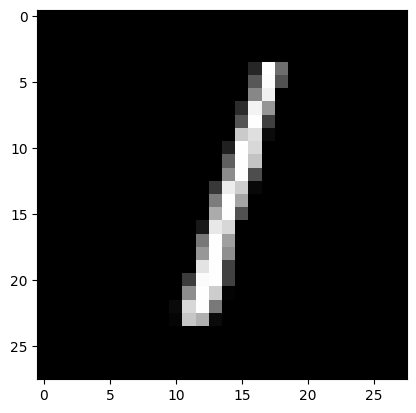

Actual: 1
Predicted: 1


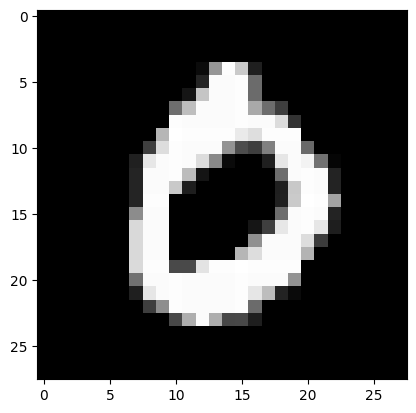

Actual: 0
Predicted: 0


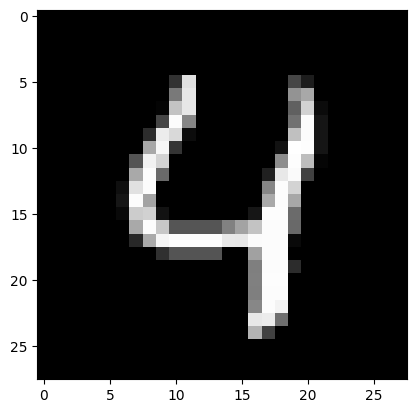

Actual: 4
Predicted: 4


In [ ]:
for i in range(5):

    image = X_test[i].reshape(28,28)

    plt.imshow(image, cmap='gray')
    plt.show()

    print("Actual:", y_test[i])
    print("Predicted:", y_pred[i])

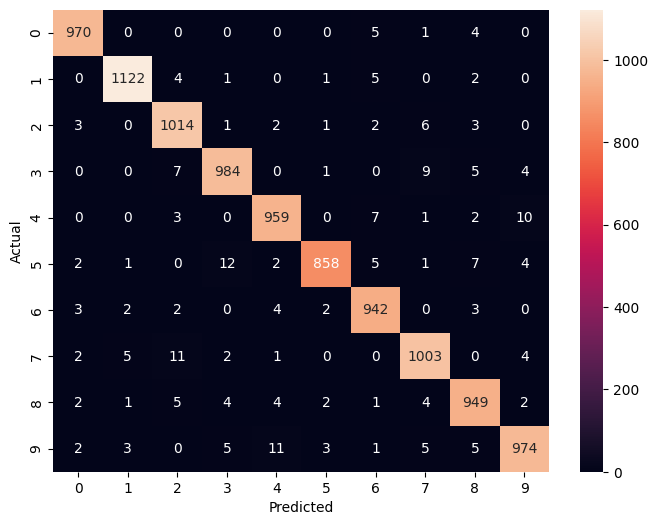

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()